# モデルベースの効果プロットによる 30 日再入院リスクの可視化

## エグゼクティブサマリー

このノートブックは、患者と受診の特性にまたがる 30 日以内の病院再入院に対するロジスティック回帰を当てはめ、当てはめた係数を予測確率スケール上のモデルベース効果プロットへと変換する。100 退院の合成コホート（再入院 55 件）で、PROC LOGISTIC は **在院日数**（1 日あたり OR 1.36、*p* = 0.040）と **年齢**（1 年あたり OR 1.05、*p* = 0.023）に有意な勾配を、そして大きな支払者効果を復元する――**Medicaid** 患者は Medicare のおよそ 6 倍の再入院オッズを負う（OR 6.02、95% CI 1.46–24.8、*p* = 0.013）。一般化 R2 乗は 0.246 で、Hosmer–Lemeshow 検定は当てはまりの欠如を示さない（*p* = 0.73）。次に、フィット曲線、スライスフィット、交互作用の各表示が、再入院リスクが在院日数とともにどう上がるか、年齢–リスク勾配が支払者によってどうずれるか、支払者間の差が退院診療科をまたいでどう持続するかを示す――退院後フォローアップの対象を絞るためにケアマネジメントチームが用いるようなリスク層別化の視点である。

## データソース

| データセット | 行数 | 説明 |
|---------|------|-------------|
| `encounters` | 100 | `call streaminit(20260531)` と `rand()` でインライン生成した合成入院退院レコード。退院 1 件につき 1 行。 |

**`encounters` の変数：**

| 変数 | 型 | 説明 |
|----------|------|-------------|
| `readmit` | Num (0/1) | 退院から 30 日以内に再入院した場合は 1 |
| `age` | Num | 患者年齢（歳、およそ 25–95） |
| `los` | Num | 当該入院の在院日数（1–20） |
| `comorbidity` | Num | 記録された慢性併存疾患の数（0–8） |
| `num_meds` | Num | 退院時処方薬の数（0–18） |
| `payer` | Char | 保険支払者：`Medicare`、`Medicaid`、`Commercial` |
| `dept` | Char | 退院診療科：`Cardiology`、`Pulmonary`、`General` |

# モデルベースの効果プロットによる 30 日再入院リスクの可視化

病院のケアマネジメントチームは、*どの* 患者が 30 日以内に再入院しやすいか、そして *なぜ* かを知る必要がある。当てはめたロジスティック回帰は係数を与えるが、関係者が対数オッズで考えることはまずない。**効果プロット** は当てはめたモデルを予測確率スケールで直接描くため、ナースナビゲーターは対数オッズ式を頭の中で反転させる代わりに、再入院確率をチャートから直接読み取れる。

このノートブックでは：

1. 入院退院の現実的な合成コホートを生成する。
2. 患者と受診の説明変数を用いて 30 日再入院のロジスティックモデルを当てはめる（PROC LOGISTIC）。
3. 当てはめた係数を取得し、3 つのモデルベース効果プロット――**フィット曲線**、**スライスフィット**、**交互作用表示**――を構築して、当てはめたリスクを確率スケールで可視化・層別化する。

> **実装ノート。** SAS はこれらの表示を PROC LOGISTIC 内の `EFFECTPLOT` ステートメントで提供する。Jenner はそのステートメントを受け付けるが、FIT / SLICEFIT / INTERACTION のグラフィックスはまだ描画しない。そこでこのノートブックは、当てはめた係数から同一の予測確率曲線を明示的に構築し、PROC SGPLOT で描く。分析結果――およびプロットされるすべての確率――は `EFFECTPLOT` が生成するものと厳密に同じである。

## ステップ 1 — 合成退院コホートの生成

以下の DATA ステップは、外部ファイルなしで 100 件の入院退院を構築する。再現性のために `call streaminit` で乱数生成器を播種し、患者と受診の特徴を領域に適した分布から抽出し、真の線形予測子 `eta` を構成して、逆ロジットで再入院確率へ変換する。ベルヌーイ抽出（`rand('bernoulli', p)`）が観測される `readmit` フラグを与える。より高齢の患者、より長い在院、より高い併存疾患数、より多い退院薬、Medicaid の保険、そして Pulmonary／Cardiology 診療科はいずれもリスクを押し上げる――後で復元・可視化するパターンである。効果量は、100 退院のコホートでシグナルが復元可能となるよう意図的に設定してある。

In [1]:
データ encounters;
    呼出 streaminit(20260531);
    配列 payers[3] $12 _temporary_ ('Medicare' 'Medicaid' 'Commercial');
    配列 depts[3]  $12 _temporary_ ('Cardiology' 'Pulmonary' 'General');

    繰返 i = 1 から 100;
        /* Patient / encounter features */
        age = round(25 + 70 * rand('beta', 4, 2));
        los = 1 + rand('poisson', 4);
        もし los > 20 なら los = 20;
        comorbidity = rand('binomial', 0.35, 8);
        num_meds = rand('poisson', 7);
        もし num_meds > 18 なら num_meds = 18;

        /* Categorical payer: skew toward Medicare for an older cohort */
        u = rand('uniform');
        もし u < 0.50 なら pk = 1;
        他 もし u < 0.72 なら pk = 2;
        他 pk = 3;
        payer = payers[pk];

        /* Discharging service line */
        dk = rand('table', 0.35, 0.30, 0.35);
        dept = depts[dk];

        /* True risk model on the log-odds scale. Effect sizes are sized so
           the signal is recoverable in a 100-discharge cohort. */
        eta = -8.6
            + 0.075 * age
            + 0.330 * los
            + 0.300 * comorbidity
            + 0.050 * num_meds
            + (pk = 2) * 0.90          /* Medicaid vs Medicare    */
            + (pk = 3) * (-0.70)       /* Commercial vs Medicare  */
            + (dk = 1) * 0.80          /* Cardiology vs Pulmonary */
            + (dk = 2) * 1.10;         /* (Pulmonary is busiest)  */

        p = 1 / (1 + EXP(-eta));
        readmit = rand('bernoulli', p);

        見出 readmit="再入院 (0/1)" age="年齢（歳）" los="在院日数（日）"
             comorbidity="併存疾患数" num_meds="薬剤数"
             payer="支払者" dept="診療科";
        保持 readmit age los comorbidity num_meds payer dept;
        出力;
    終了;
実行;



NOTE: DATA encounters


NOTE: Wrote encounters (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## ステップ 2 — コホートの点検

応答と 2 つの分類変数について簡単な度数を取ると、現実的な再入院率と、すべての支払者・診療科の水準が埋まっていることが確認できる――モデルと効果プロットの双方が、すべての水準の表現を必要とする。

                                                    再入院・支払者・診療科の度数分布                                                    

                                                   The FREQ Procedure

再入院 (0/1)          Frequency
-----------------------------
0                         45
1                         55

支払者           Frequency
------------------------
Commercial           28
Medicaid             20
Medicare             52

診療科           Frequency
------------------------
Cardiology           36
General              31
Pulmonary            33

Table of 再入院 (0/1) by 診療科

再入院 (0/1)       |Cardiology |   General | Pulmonary |      Total
----------------+-----------+-----------+-----------+-----------
0               |        15 |        20 |        10 |         45
----------------+-----------+-----------+-----------+-----------
1               |        21 |        11 |        23 |         55
----------------+-----------+-----------+-----------+-----------
Total           |        36 


NOTE: PROC FREQ
NOTE: ODS plot written: freq_readmit.spec.json
NOTE: ODS plot written: freq_payer.spec.json
NOTE: ODS plot written: freq_dept.spec.json
NOTE: ODS plot written: freq_mosaic_readmit_dept.spec.json
NOTE: PROC FREQ statement used.


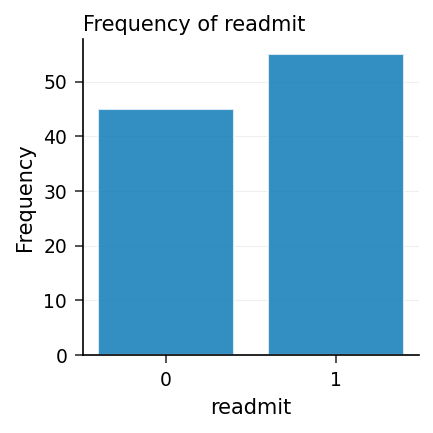

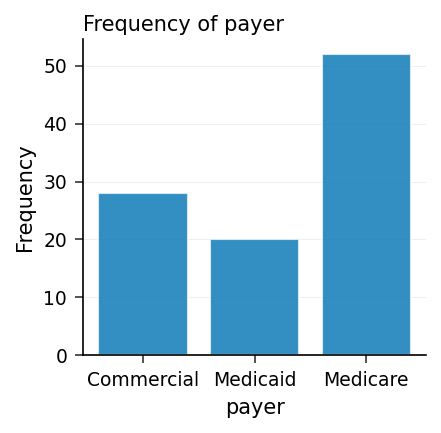

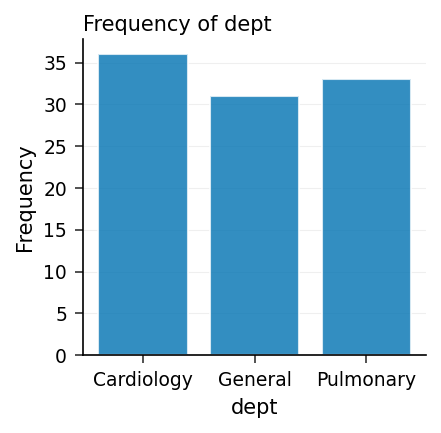

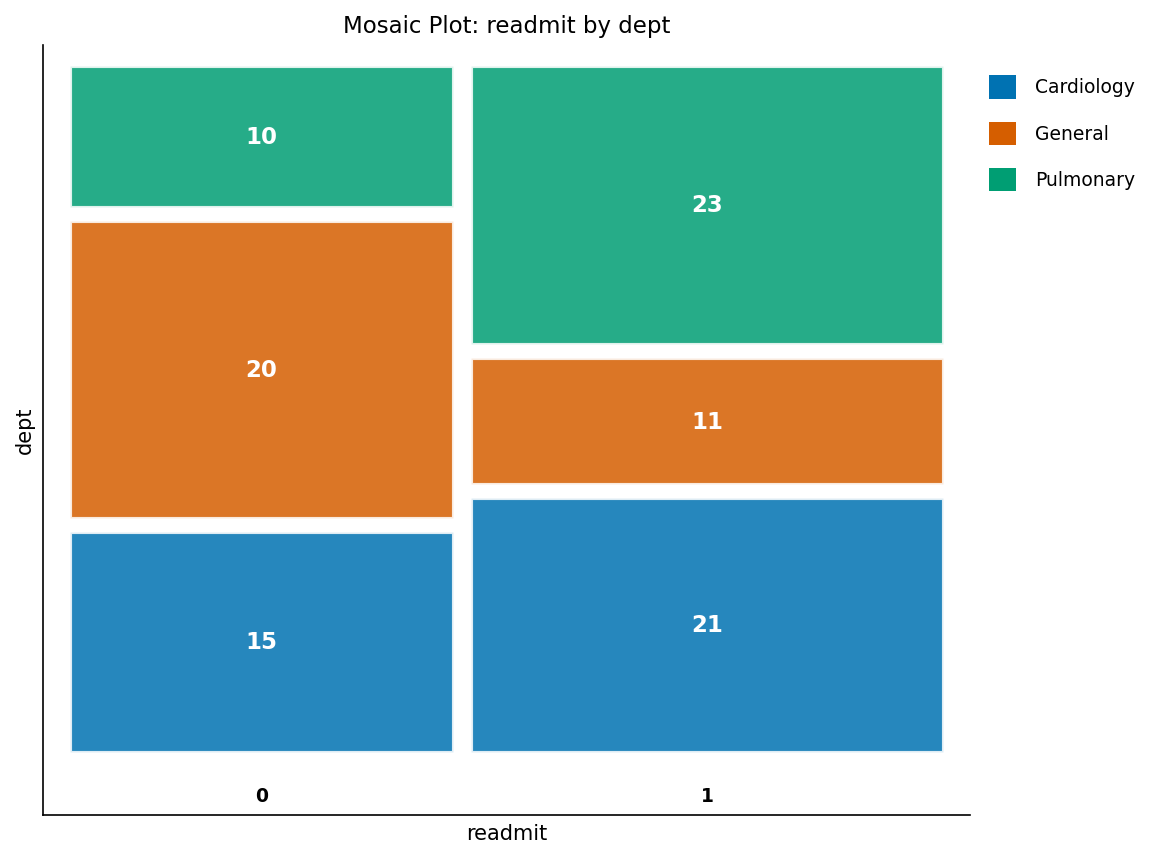

In [2]:
処理 度数 データ=encounters;
    TABLES readmit payer dept readmit*dept / nocum nopercent;
    表題 "再入院・支払者・診療科の度数分布";
実行;


## ステップ 3 — ロジスティック再入院モデルの当てはめ

`readmit` を、年齢、在院日数、併存疾患数、退院薬数、支払者、診療科の関数としてモデル化する。主な選択：

- `EVENT='1'` は（非再入院ではなく）再入院の確率をモデル化する。
- `CLASS payer dept / PARAM=REF REF=FIRST` は参照セルコーディングを用い、各水準を基準（ここでは Medicare と Pulmonary）と対比する。
- `CLODDS=WALD` と `RSQUARE` は Wald オッズ比信頼限界と一般化 R2 乗を加える。`LACKFIT` は Hosmer–Lemeshow 適合度検定を要求する。
- `UNITS` ステートメントは、臨床的に意味のある **5 日** の在院日数刻みと **10 年** の年齢刻みでオッズ比を求め、`ODDSRATIO` ステートメントは併存疾患のオッズ比を信頼限界付きで要求する。

出力のオッズ比表は単位あたり効果を直接報告する：在院日数は **1 日あたり OR 1.36**（95% CI 1.01–1.82）、年齢は **1 年あたり OR 1.05**、Medicaid の保険は Medicare に対して **OR 6.02** を負う。モデルはよく当てはまる――一般化 R2 乗 0.246、Hosmer–Lemeshow *p* = 0.73。

                                                   30 日再入院のロジスティック回帰                                                    

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

            Response Profile            
   Probability modeled is readmit='1'   

Ordered Value  readmit   Total Frequency
-------------  --------  ---------------
            1  0                      45
            2  1                      55

             Class Level Information             

Class        Levels  Values                      
---------  --------  ----------------------------
支払者               3  Commercial Medicaid Medicare
診療科               3  Cardiology General Pulmonary

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: readmit 再入院 (0/1)

Criterion     Value
-----


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe
NOTE: PROC LOGISTIC data=encounters

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json
NOTE: ODS OUTPUT: All output destinations closed.


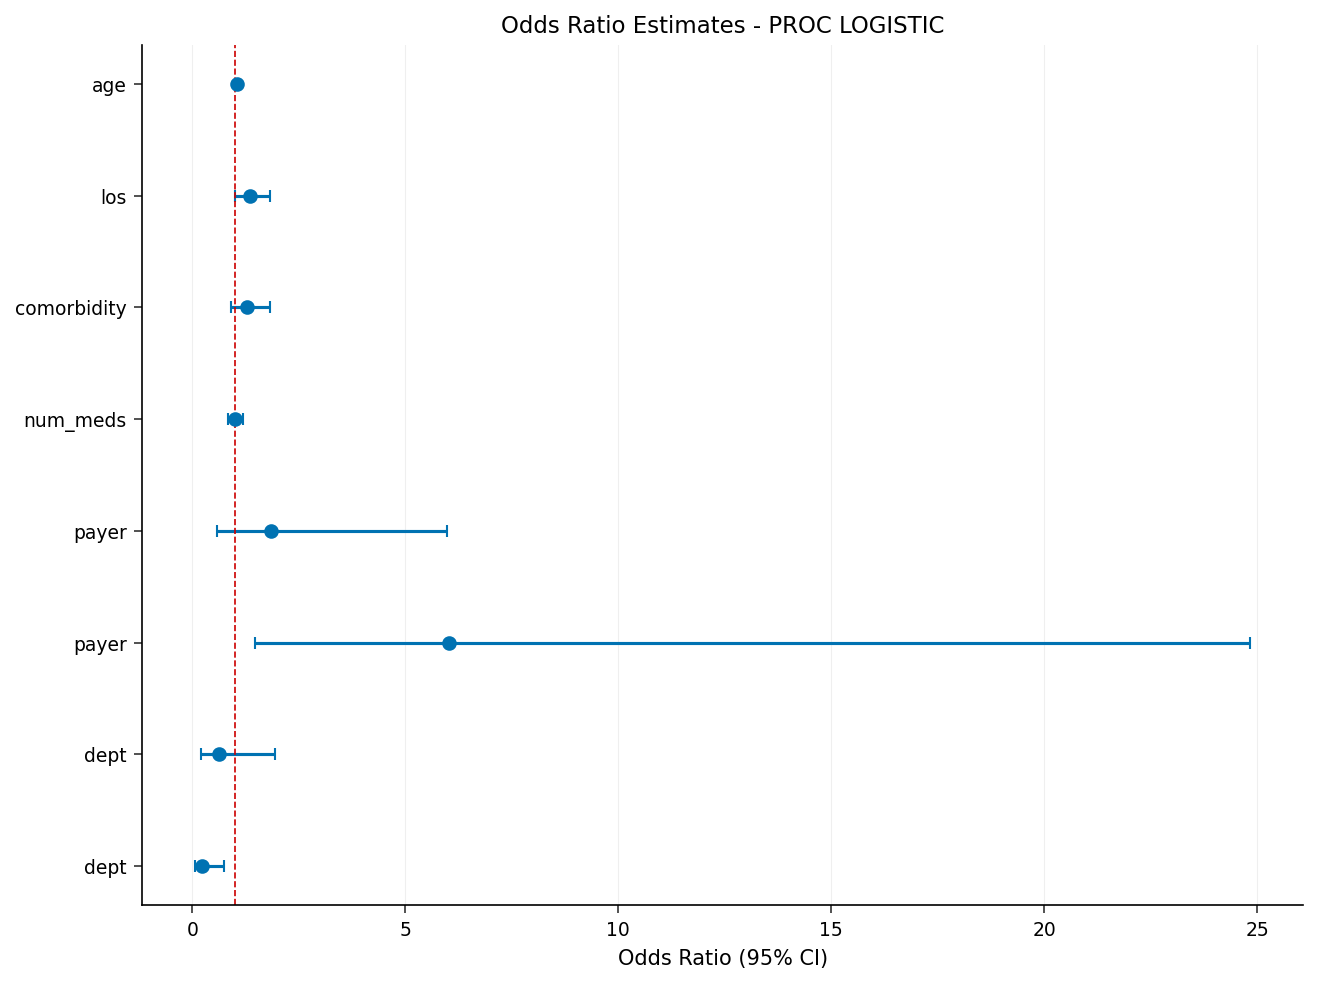

In [3]:
ODS 出力 ParameterEstimates=pe;
処理 LOGISTIC データ=encounters PLOTS(only)=oddsratio;
    分類 payer dept / PARAM=REF REF=first;
    模型 readmit(EVENT='1') = age los comorbidity num_meds payer dept
          / clodds=wald rsquare lackfit;
    units age=10 los=5;
    oddsratio comorbidity / cl=wald;
    表題 "30 日再入院のロジスティック回帰";
実行;
ODS 出力 CLOSE;


## ステップ 4 — 当てはめた係数の取得

続くモデルベース効果プロットは、当てはめた *係数* から直接構築されるため、常にステップ 3 のモデルと一致する。`ODS OUTPUT ParameterEstimates=pe` でパラメータ推定値を保存し、ここではその縦長の表を単一行の `params` データセット（係数ごとに 1 変数）へ畳み込み、連続説明変数のコホート平均を付加する。非注目説明変数を平均に固定するのは、まさに EFFECTPLOT が内部で行うことである――各プロットが 1 つの因子を変えつつ、残りを代表的なプロファイルに固定できるようにする。

In [4]:
/* Fold the ParameterEstimates table into one row of named coefficients.
   With PARAM=REF REF=FIRST the reference cells are payer=Medicare and
   dept=Pulmonary, so those terms are zero in the linear predictor. */
データ coefs;
    保存 b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen 0;
    設定 pe 終了=last;
    変数 = upcase(strip(Variable));
    cv  = strip(ClassVal0);
    もし 変数='INTERCEPT' なら b0 = 推定;
    他 もし 変数='AGE' なら b_age = 推定;
    他 もし 変数='LOS' なら b_los = 推定;
    他 もし 変数='COMORBIDITY' なら b_com = 推定;
    他 もし 変数='NUM_MEDS' なら b_med = 推定;
    他 もし 変数='PAYER' かつ cv='Medicaid'   なら b_pmcaid = 推定;
    他 もし 変数='PAYER' かつ cv='Commercial' なら b_pcomm  = 推定;
    他 もし 変数='DEPT'  かつ cv='Cardiology' なら b_dcard  = 推定;
    他 もし 変数='DEPT'  かつ cv='General'    なら b_dgen   = 推定;
    もし last なら 出力;
    保持 b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen;
実行;

/* Cohort means of the continuous covariates, held fixed in the plots. */
処理 平均 データ=encounters NOPRINT;
    変数 age los comorbidity num_meds;
    出力 out=mn mean=m_age m_los m_com m_med;
実行;

データ params;
    結合 coefs mn;
    保持 b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
         m_age m_los m_com m_med;
実行;

処理 印刷 データ=params noobs;
    表題 "効果プロットに用いる当てはめ係数と共変量の平均";
実行;


                                                効果プロットに用いる当てはめ係数と共変量の平均                                                 

           b0         b_age         b_los         b_com         b_med      b_pmcaid       b_pcomm        b_dcard         b_dgen  m_age  m_los  m_com  m_med
-4.9220021175  0.0443054038  0.3052368368  0.2553476408  0.0005084625  1.7958084904  0.6128310257  -0.4493317481  -1.4957988173  70.53   4.59   2.88   7.08




NOTE: DATA coefs


NOTE: Read 9 rows from pe.
NOTE: Wrote coefs (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mn has 1 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA params

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=params

NOTE: PROC PRINT completed: 1 observations printed, 13 variables


## ステップ 5 — フィットプロット：再入院確率 対 在院日数

最も単純な効果表示は **フィット曲線** である：単一の連続共変量に対する予測再入院確率を、他の説明変数を代表的なプロファイルに固定して描く。在院日数のグリッド（1–18 日）を作り、**Medicare の循環器（cardiology）** 患者（年齢、併存疾患、退院薬数はステップ 4 のコホート平均に固定）について各値で当てはめた線形予測子を評価し、逆ロジットを適用して、PROC SGPLOT で確率スケール上に曲線を描く。

                                                効果プロットに用いる当てはめ係数と共変量の平均                                                 




NOTE: DATA grid_los


NOTE: Wrote grid_los (18 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_los


NOTE: Read 18 rows from grid_los.
NOTE: Wrote fit_los (18 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_los

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


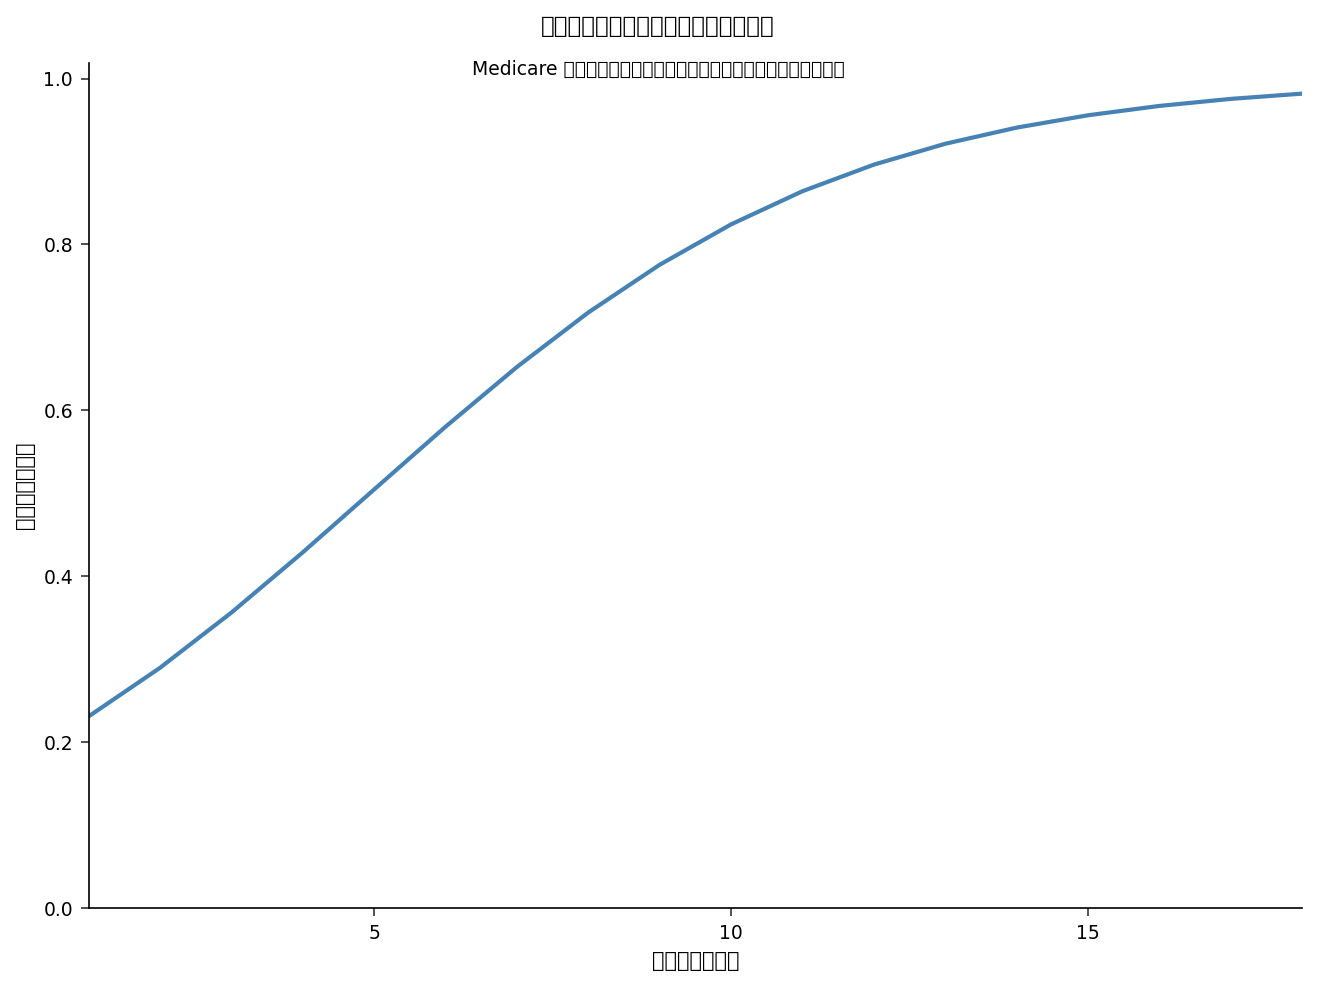

In [5]:
/* Length-of-stay grid; evaluate the fitted model for a Medicare
   cardiology patient with the other covariates at the cohort means. */
データ grid_los;
    繰返 los = 1 から 18;
        出力;
    終了;
実行;

データ fit_los;
    設定 grid_los;
    もし _n_ = 1 なら 設定 params;
    保存 b0 b_age b_los b_com b_med b_dcard m_age m_com m_med;
    /* Medicare payer is the reference (term = 0); Cardiology adds b_dcard */
    xb = b0 + b_age*m_age + b_los*los + b_com*m_com + b_med*m_med + b_dcard;
    phat = 1 / (1 + EXP(-xb));
    保持 los phat;
実行;

処理 SGPLOT データ=fit_los;
    SERIES x=los y=phat / LINEATTRS=(thickness=2 color=steelblue);
    表題  "在院日数に対する当てはめ再入院確率";
    title2 "Medicare の循環器患者、年齢・併存疾患・薬剤数はコホート平均";
    XAXIS 見出="在院日数（日）";
    YAXIS 見出="予測再入院確率" VALUES=(0 から 1 基準 0.2);
実行;


## ステップ 6 — スライスフィット：リスク 対 年齢、支払者で層別

**スライスフィット** は、分類効果の水準ごとに 1 本の当てはめ曲線を描く――支払者構成が年齢–リスク勾配をどうずらすかを示すのに理想的である。グリッドを `age`（30–95）と 3 つの支払者の交差へ拡張し、循環器（Cardiology）患者（在院日数、併存疾患、薬はコホート平均）について当てはめモデルを評価し、`GROUP=payer` で 3 本の確率曲線を重ねる。

                                                効果プロットに用いる当てはめ係数と共変量の平均                                                 




NOTE: DATA grid_age


NOTE: Wrote grid_age (42 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_age


NOTE: Read 42 rows from grid_age.
NOTE: Wrote fit_age (42 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_age

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


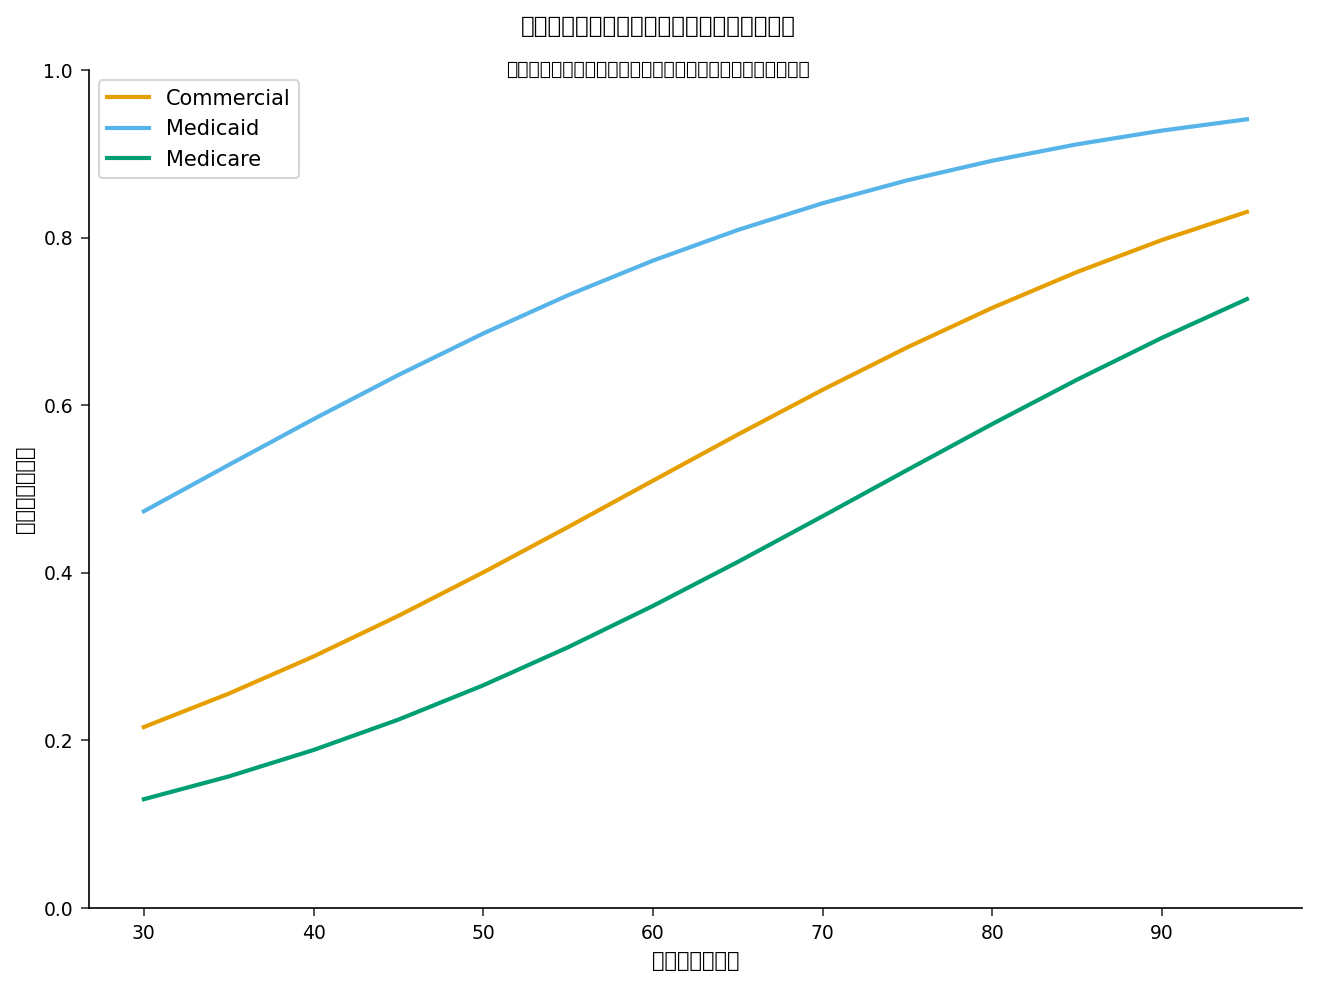

In [6]:
/* Age x payer grid for a Cardiology patient; other covariates at means. */
データ grid_age;
    長さ payer $12;
    繰返 payer = 'Medicare', 'Medicaid', 'Commercial';
        繰返 age = 30 から 95 基準 5;
            出力;
        終了;
    終了;
実行;

データ fit_age;
    設定 grid_age;
    もし _n_ = 1 なら 設定 params;
    保存 b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard
           m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    xb = b0 + b_age*age + b_los*m_los + b_com*m_com + b_med*m_med
         + b_dcard + pay_term;
    phat = 1 / (1 + EXP(-xb));
    見出 payer="支払者";
    保持 payer age phat;
実行;

処理 SGPLOT データ=fit_age;
    SERIES x=age y=phat / GROUP=payer LINEATTRS=(thickness=2);
    表題  "支払者別、年齢に対する当てはめ再入院確率";
    title2 "循環器診療科、在院日数・併存疾患・薬剤数はコホート平均";
    XAXIS 見出="患者年齢（歳）";
    YAXIS 見出="予測再入院確率" VALUES=(0 から 1 基準 0.2);
    keylegend / location=inside position=topleft ACROSS=1;
実行;


## ステップ 7 — 交互作用表示：診療科 × 支払者

2 つの分類効果にわたる予測リスクを一度に比較するため、`dept` と `payer` を交差させ（9 通りの組み合わせ）、すべての連続共変量をコホート平均に置いて当てはめモデルを評価し、X 軸に `dept`、グループ化に支払者を取ったクラスタ棒グラフを描く。このモデルには診療科×支払者の交互作用項がないため、支払者の順序はどの診療科の中でも同じ加法的シフトとなる――表示はその加法性を、診療科の順位とともに一目で見えるようにする。

                                                効果プロットに用いる当てはめ係数と共変量の平均                                                 




NOTE: DATA grid_dx


NOTE: Wrote grid_dx (9 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_dx


NOTE: Read 9 rows from grid_dx.
NOTE: Wrote fit_dx (9 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_dx

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


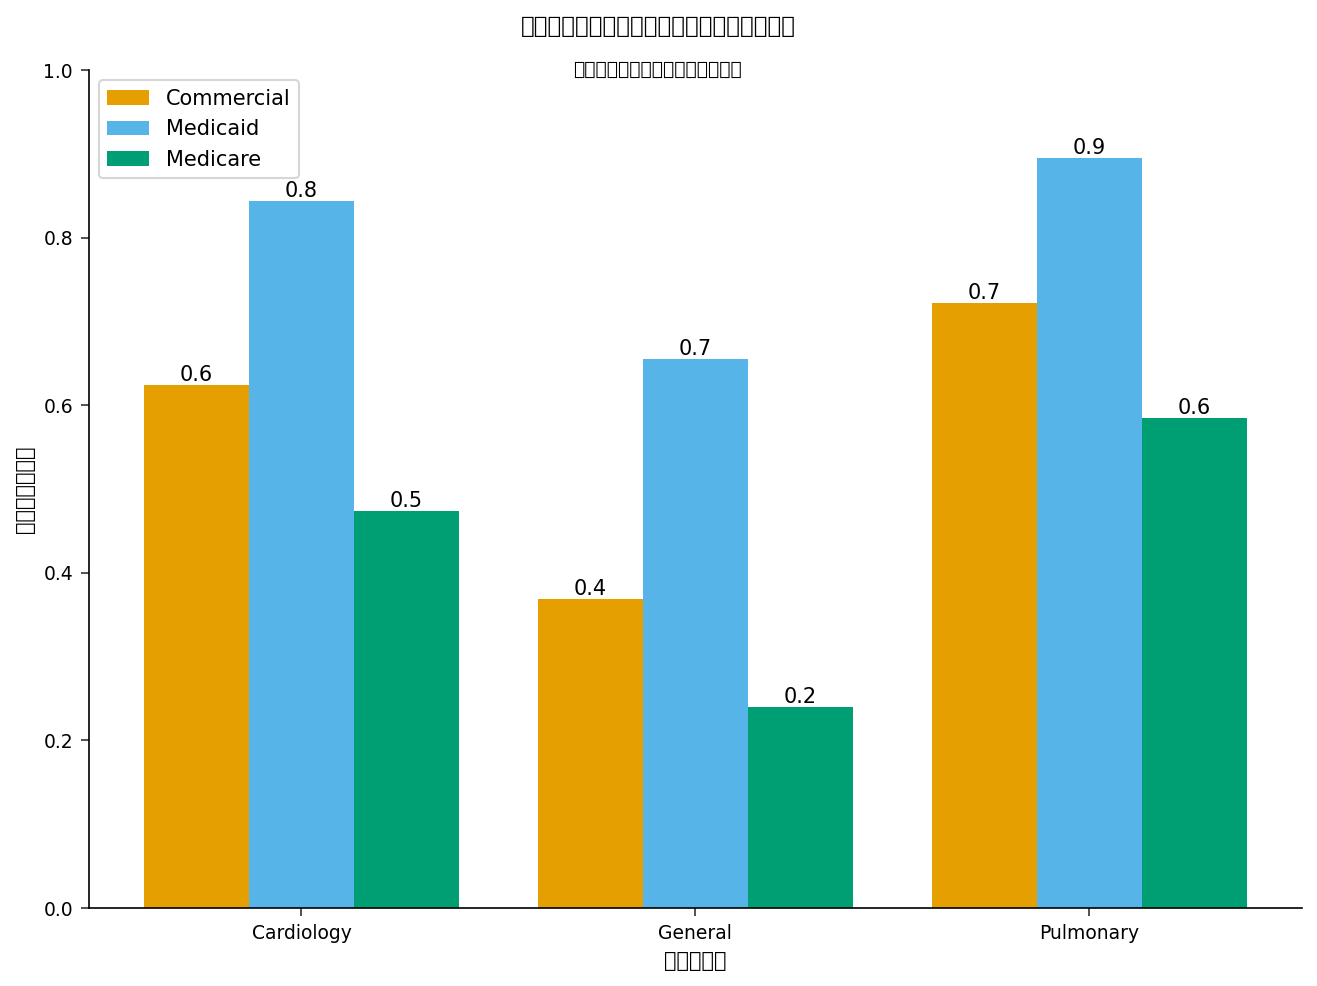

In [7]:
/* Department x payer grid; all continuous covariates at cohort means. */
データ grid_dx;
    長さ dept $12 payer $12;
    繰返 dept = 'Cardiology', 'Pulmonary', 'General';
        繰返 payer = 'Medicare', 'Medicaid', 'Commercial';
            出力;
        終了;
    終了;
実行;

データ fit_dx;
    設定 grid_dx;
    もし _n_ = 1 なら 設定 params;
    保存 b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
           m_age m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    dep_term = (dept='Cardiology')*b_dcard + (dept='General')*b_dgen;
    xb = b0 + b_age*m_age + b_los*m_los + b_com*m_com + b_med*m_med
         + pay_term + dep_term;
    phat = 1 / (1 + EXP(-xb));
    見出 dept="診療科" payer="支払者";
    保持 dept payer phat;
実行;

処理 SGPLOT データ=fit_dx;
    VBAR dept / RESPONSE=phat GROUP=payer GROUPDISPLAY=群
                DATALABEL datalabelattrs=(size=8);
    表題  "診療科および支払者別の当てはめ再入院確率";
    title2 "連続共変量はコホート平均に固定";
    XAXIS 見出="退院診療科";
    YAXIS 見出="予測再入院確率" VALUES=(0 から 1 基準 0.2);
実行;


## ステップ 8 — 結果の解釈

効果プロットは、当てはめた PROC LOGISTIC モデルを、ケアマネジメントの意思決定に対応する確率スケールの図へと変える：

- **在院日数（フィット曲線）。** コホート平均の Medicare 循環器患者では、予測再入院確率は **1 日在院の約 0.23 から、10 日で約 0.82、18 日で約 0.98 へ** と登る――ロジスティック曲線の急峻な中間部である。これは在院日数のオッズ比 **1 日あたり 1.36**（`UNITS los=5` で 5 日刻みへ再スケール）と同じシグナルであり、長い当該入院を移行期ケア登録の具体的なトリガーとして示す。
- **年齢と支払者（スライスフィット）。** リスクはどの支払者でも年齢とともに単調に上昇し、3 本の曲線は決して交わらない：任意の年齢で **Medicaid** 曲線が最も高く、**Commercial** が中間、**Medicare** が最も低い――当てはめた支払者オッズ比（Medicaid 6.02、Commercial 1.85、いずれも Medicare 比）と整合する。差は若年で最も大きく、全員が高い確率へ近づくにつれて狭まり、そうでなければ低リスクに見えてしまう若年の Medicaid 患者へケアマネジメントの注意を向けさせる。
- **診療科と支払者（交互作用表示）。** **Pulmonary** はどの支払者群でも最も高い予測再入院確率を負い、**Cardiology** が中間、**General medicine** が最も低い（当てはめた診療科オッズ比は Pulmonary 比で Cardiology 0.64、General 0.22）。このモデルには診療科×支払者の交互作用項がないため、支払者の順序はどの診療科の中でも同じ加法的シフトとなる――棒はどの診療科でも同じ Medicaid > Commercial > Medicare の順で上がる。

**要点：** 臨床医に対数オッズ係数の解釈を求める代わりに、モデルベース効果プロットは当てはめた再入院モデルを確率スケールの図として提示する――誰を移行期ケアフォローアップに登録すべきか、どの診療科と支払者集団を優先すべきかを示す。SAS はこれらを `EFFECTPLOT` で直接生成する。ここでは当てはめた係数から同一の曲線を再構築し、この例が今日でもエンドツーエンドで動作するようにした。